# Exploratory Data Analysis: IRC Poker Dataset (Sampled Subset)

This notebook performs exploratory data analysis on a sampled subset of the IRC Texas Hold'em Poker Dataset.

## Goals
- Parse raw poker log data
- Extract player-level behavioral features
- Compute VPIP and PFR for each player
- Visualize feature distributions
- Analyze relationships between features
- Build a heuristic baseline for player profiling

Because the full dataset is very large, this analysis uses a cached sampled subset for computational feasibility.

In [7]:
import os
import sys
import re
import gzip
import random
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

## Environment Setup

We mount Google Drive, define the dataset path, and set visualization defaults.

In [ ]:
drive.mount('/content/drive')

DATA_DIR = '/content/drive/My Drive/CS 4824 Group Project/data/raw/holdem'
CACHE_PATH = '/content/drive/MyDrive/CS 4824 Group Project/data/intermediate/raw_data_sampled.csv'

sys.path.append(DATA_DIR)
os.chdir(DATA_DIR)

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
plt.rcParams['figure.dpi'] = 120

MIN_HANDS = 30
RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Parsing Raw Poker Logs

Each raw log file contains hand history information for a player. The function below parses a single file and extracts one record per player-hand instance.

Each record includes:
- player name
- hand ID
- number of players
- seat position
- action strings for pre-flop, flop, turn, and river

In [9]:
def parse_pdb_file(filepath):
    """
    Parse a single IRC poker log file into a list of player-hand records.
    Supports both plain text files and gzip-compressed files.
    """
    records = []
    opener = gzip.open if filepath.endswith('.gz') else open

    try:
        with opener(filepath, 'rt', errors='replace') as f:
            for line in f:
                parts = line.split()
                if len(parts) < 5:
                    continue

                records.append({
                    'player': parts[0],
                    'hand_id': parts[1],
                    'num_players': parts[2],
                    'position': parts[3],
                    'preflop_actions': parts[4],
                    'flop_actions': parts[5] if len(parts) > 5 else '-',
                    'turn_actions': parts[6] if len(parts) > 6 else '-',
                    'river_actions': parts[7] if len(parts) > 7 else '-',
                })
    except Exception:
        pass

    return records

## Defining VPIP and PFR

We extract two common poker statistics from the pre-flop action string:

- **VPIP (Voluntarily Put Money in Pot):** 1 if a player voluntarily enters the pot pre-flop
- **PFR (Pre-Flop Raise):** 1 if a player raises pre-flop

Forced blind posts are excluded from VPIP.

In [10]:
def compute_vpip_pfr(preflop_actions):
    """
    Compute VPIP and PFR flags from a pre-flop action string.

    VPIP = 1 if player voluntarily put money in the pot
    PFR  = 1 if player raised pre-flop
    """
    if preflop_actions == '-':
        return 0, 0

    voluntary_actions = preflop_actions.replace('B', '')  # ignore blind posts
    vpip = int(bool(re.search(r'[bcrA]', voluntary_actions)))
    pfr = int(bool(re.search(r'[rA]', voluntary_actions)))

    return vpip, pfr

## Quick Parsing Sanity Check

Before loading the cached dataset, we test the parser on a single file to make sure the format is being read correctly.

In [ ]:
test_file = '/content/drive/My Drive/CS 4824 Group Project/data/raw/holdem/199507/pdb/pdb.Antonio'
test_records = parse_pdb_file(test_file)

print(f'{len(test_records)} records')
if test_records:
    print('First record:', test_records[0])

245 records
First record: {'player': 'Antonio', 'hand_id': '804709900', 'num_players': '4', 'position': '2', 'preflop_actions': 'Br', 'flop_actions': '-', 'turn_actions': '-', 'river_actions': '-'}


## Loading or Creating Cached Parsed Data

If a cached parsed dataset exists, we load it directly.  
Otherwise, we parse a sampled subset of the raw logs and save it for future use.

In [12]:
if os.path.exists(CACHE_PATH):
    print("Cached file found. Loading...")
    raw_df = pd.read_csv(CACHE_PATH)
else:
    print("Cached file NOT found. Parsing raw dataset (this may take a while)...")

    all_files = glob.glob(os.path.join(DATA_DIR, '**/pdb.*'), recursive=True)

    # Sample a subset for speed
    SAMPLE_SIZE = min(500, len(all_files))  # adjust if needed
    sampled_files = random.sample(all_files, SAMPLE_SIZE)

    all_records = []

    for i, file in enumerate(sampled_files):
        if i % 50 == 0:
            print(f"Processing file {i+1}/{SAMPLE_SIZE}")
        records = parse_pdb_file(file)
        all_records.extend(records)

    raw_df = pd.DataFrame(all_records)

    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)

    raw_df.to_csv(CACHE_PATH, index=False)
    print(f"Saved parsed data to: {CACHE_PATH}")

print(f'Loaded {len(raw_df):,} parsed records')
raw_df.head()

Cached file NOT found. Parsing raw dataset (this may take a while)...
Processing file 1/500
Processing file 51/500
Processing file 101/500
Processing file 151/500
Processing file 201/500
Processing file 251/500
Processing file 301/500
Processing file 351/500
Processing file 401/500
Processing file 451/500
Saved parsed data to: /content/drive/MyDrive/CS 4824 Group Project/data/intermediate/raw_data_sampled.csv
Loaded 115,666 parsed records


,player,hand_id,num_players,position,preflop_actions,flop_actions,turn_actions,river_actions
0,ccv,831950840,8,7,f,-,-,-
1,ccv,831950892,9,6,f,-,-,-
2,ccv,831950966,11,5,KQ,-,-,-
3,ccv,831952799,10,9,f,-,-,-
4,ccv,831952874,10,8,f,-,-,-


## Computing Player-Level VPIP and PFR

We now:
1. Compute VPIP and PFR flags for each player-hand record
2. Aggregate these values at the player level
3. Compute each player's overall VPIP and PFR percentages
4. Filter out players with fewer than 30 hands

In [13]:
vpip_flags = []
pfr_flags = []

for actions in raw_df['preflop_actions']:
    vpip, pfr = compute_vpip_pfr(str(actions))
    vpip_flags.append(vpip)
    pfr_flags.append(pfr)

raw_df['vpip_flag'] = vpip_flags
raw_df['pfr_flag'] = pfr_flags

player_stats = raw_df.groupby('player').agg(
    total_hands=('hand_id', 'count'),
    vpip_hands=('vpip_flag', 'sum'),
    pfr_hands=('pfr_flag', 'sum')
).reset_index()

player_stats['VPIP'] = (player_stats['vpip_hands'] / player_stats['total_hands']) * 100
player_stats['PFR'] = (player_stats['pfr_hands'] / player_stats['total_hands']) * 100

player_stats = player_stats[player_stats['total_hands'] >= MIN_HANDS].reset_index(drop=True)

print(f'Players with >= {MIN_HANDS} hands: {len(player_stats):,}')
player_stats[['player', 'total_hands', 'VPIP', 'PFR']].describe().round(2)

Players with >= 30 hands: 344


,total_hands,VPIP,PFR
count,344.00,344.00,344.00
mean,331.71,46.90,13.10
std,469.27,18.50,14.17
min,31.00,8.33,0.00
25%,72.00,33.33,4.76
50%,147.00,43.46,9.17
75%,366.50,58.34,15.75
max,3598.00,100.00,100.00


## Visualizing Feature Distributions

We examine the distributions of:
- VPIP
- PFR
- total hands played per player

In this sampled subset, the filtered table contains 344 players with average VPIP around 46.9% and average PFR around 13.1%. The plots show that participation is fairly broad across players, but aggressive pre-flop raising is much less common than simply entering pots. The hands-played histogram is also strongly right-skewed, which reinforces why a minimum-hands filter is useful before comparing player styles.


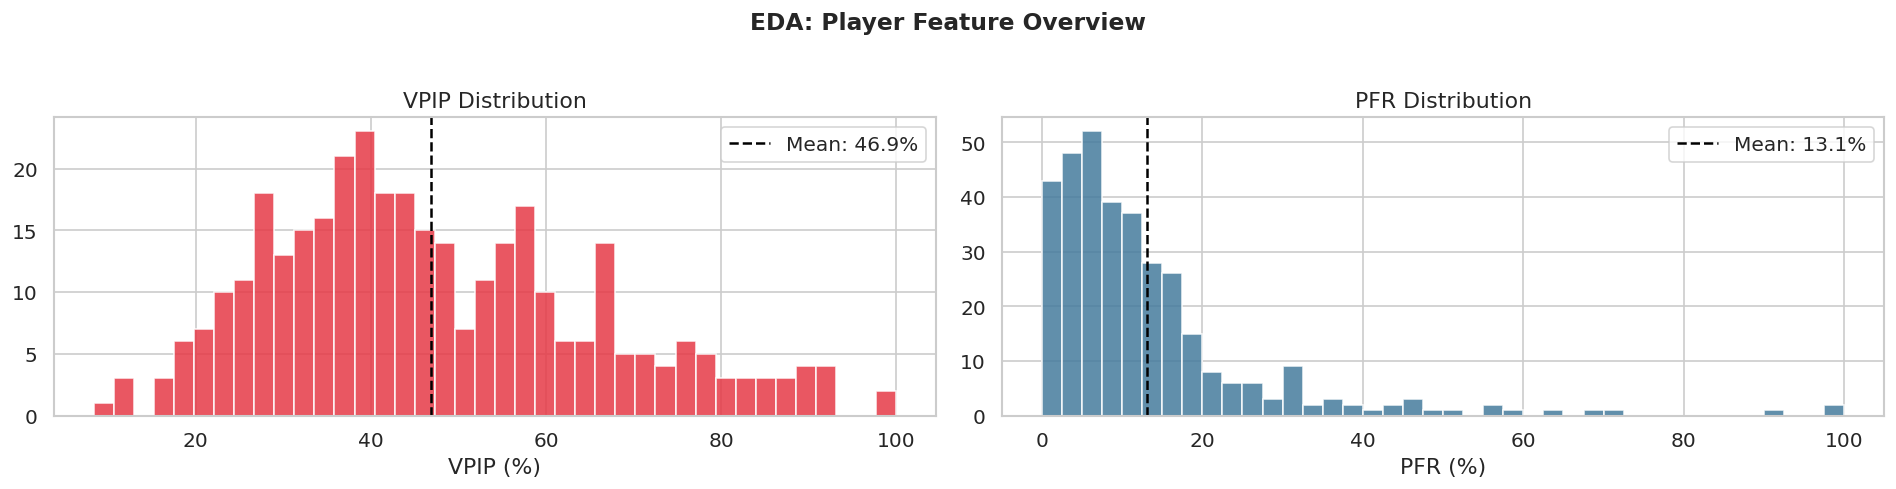

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(player_stats['VPIP'], bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(
    player_stats['VPIP'].mean(),
    color='black',
    linestyle='--',
    label=f'Mean: {player_stats["VPIP"].mean():.1f}%'
)
axes[0].set_title('VPIP Distribution')
axes[0].set_xlabel('VPIP (%)')
axes[0].legend()

axes[1].hist(player_stats['PFR'], bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(
    player_stats['PFR'].mean(),
    color='black',
    linestyle='--',
    label=f'Mean: {player_stats["PFR"].mean():.1f}%'
)
axes[1].set_title('PFR Distribution')
axes[1].set_xlabel('PFR (%)')
axes[1].legend()

plt.suptitle('EDA: Player Feature Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

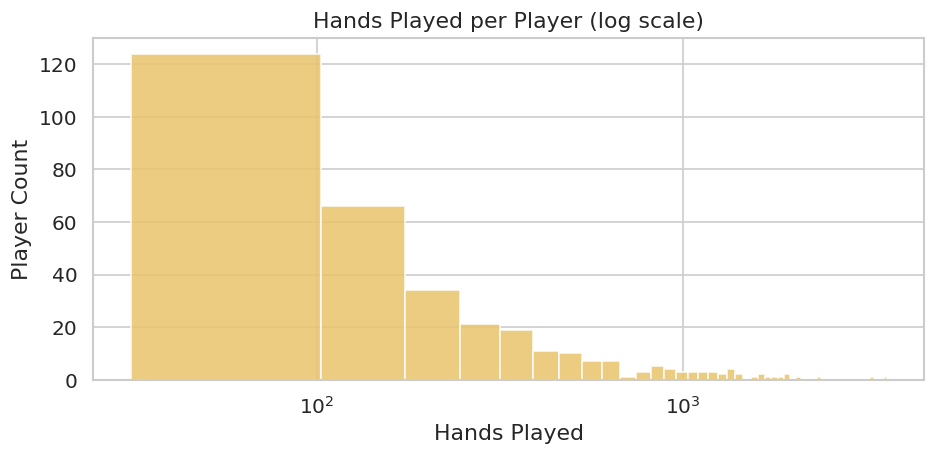

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(player_stats['total_hands'], bins=50, color=PALETTE[3], edgecolor='white', alpha=0.85)
ax.set_xscale('log')
ax.set_title('Hands Played per Player (log scale)')
ax.set_xlabel('Hands Played')
ax.set_ylabel('Player Count')
plt.tight_layout()
plt.show()

## Sanity Checks and Correlation Analysis

We perform two quick checks:
- Verify that PFR never exceeds VPIP
- Compute the correlation between VPIP, PFR, and total hands

The sanity check passes with 0 cases where PFR exceeds VPIP, which is what we would expect because a player must voluntarily enter the pot before they can raise pre-flop. The sampled data also shows a moderate positive VPIP-PFR correlation of about 0.52, suggesting that looser players often become more aggressive as well, but not so strongly that all players collapse into a single style.


In [16]:
violations = (player_stats['PFR'] > player_stats['VPIP']).sum()
print(f'Sanity check — PFR > VPIP violations: {violations} (should be 0)')

print('\nCorrelation matrix:')
display(player_stats[['VPIP', 'PFR', 'total_hands']].corr().round(3))

Sanity check — PFR > VPIP violations: 0 (should be 0)

Correlation matrix:


,VPIP,PFR,total_hands
VPIP,1.000,0.521,-0.090
PFR,0.521,1.000,-0.083
total_hands,-0.090,-0.083,1.000


While this notebook focuses on exploratory analysis, we also introduce a simple rule-based baseline to understand how players might be categorized using fixed thresholds. In the sampled subset this baseline is quite imbalanced, with most players falling into Fish or LAG and almost no TAG players, which already hints that rigid thresholds may miss some of the variation visible in the feature space.


## Heuristic Baseline

Traditional poker player archetypes can be approximated using simple VPIP/PFR thresholds:

| Type | VPIP | PFR | Description |
|------|------|-----|-------------|
| TAG  | < 25% | ≥ 15% | Tight-Aggressive |
| LAG  | ≥ 25% | ≥ 15% | Loose-Aggressive |
| Fish | ≥ 25% | < 15% | Loose-Passive |
| Rock | < 25% | < 15% | Tight-Passive |

This provides a rule-based baseline for comparison with K-Means clustering. On the sampled data, the resulting counts are heavily concentrated in Fish (216) and LAG (96), with Rock much smaller (31) and TAG nearly absent (1), so this baseline is useful mainly as a simple reference point rather than a balanced ground-truth labeling.


In [17]:
VPIP_THRESH = 25.0
PFR_THRESH = 15.0

def heuristic_label(row):
    tight = row['VPIP'] < VPIP_THRESH
    aggressive = row['PFR'] >= PFR_THRESH

    if tight and aggressive:
        return 'TAG'
    if not tight and aggressive:
        return 'LAG'
    if not tight and not aggressive:
        return 'Fish'
    return 'Rock'

player_stats['heuristic_label'] = player_stats.apply(heuristic_label, axis=1)
print(player_stats['heuristic_label'].value_counts().to_string())

heuristic_label
Fish    216
LAG      96
Rock     31
TAG       1


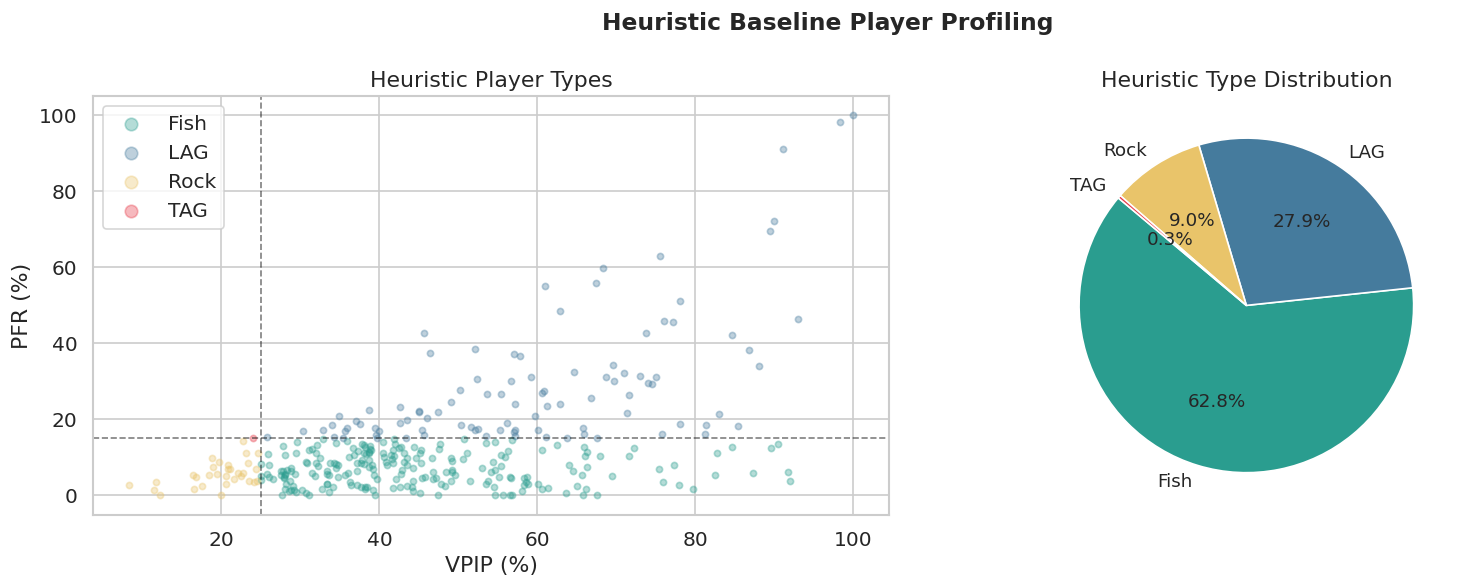

In [18]:
label_colors = {
    'TAG': PALETTE[0],
    'LAG': PALETTE[1],
    'Fish': PALETTE[2],
    'Rock': PALETTE[3]
}

label_counts = player_stats['heuristic_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in player_stats.groupby('heuristic_label'):
    axes[0].scatter(
        group['VPIP'],
        group['PFR'],
        label=label,
        alpha=0.35,
        s=14,
        color=label_colors[label]
    )

axes[0].axvline(VPIP_THRESH, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[0].axhline(PFR_THRESH, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[0].set_xlabel('VPIP (%)')
axes[0].set_ylabel('PFR (%)')
axes[0].set_title('Heuristic Player Types')
axes[0].legend(markerscale=2)

axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[label_colors[label] for label in label_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11}
)
axes[1].set_title('Heuristic Type Distribution')

plt.suptitle('Heuristic Baseline Player Profiling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Save Processed Player-Level Features

This file will be used as input to the clustering notebook.

In [19]:
PLAYER_STATS_PATH = '/content/drive/MyDrive/CS 4824 Group Project/data/processed/player_stats_sampled.csv'

player_stats.to_csv(PLAYER_STATS_PATH, index=False)
print(f'Saved processed player-level features to: {PLAYER_STATS_PATH}')
player_stats.head()

Saved processed player-level features to: /content/drive/MyDrive/CS 4824 Group Project/data/processed/player_stats_sampled.csv


,player,total_hands,vpip_hands,pfr_hands,VPIP,PFR,heuristic_label
0,AROD,1336,763,497,57.110778,37.200599,LAG
1,Aesop,176,89,17,50.568182,9.659091,Fish
2,AlexPOgan,188,74,10,39.361702,5.319149,Fish
3,Apus,40,27,6,67.500000,15.000000,LAG
4,Arnie,148,75,22,50.675676,14.864865,Fish


## Summary

In this notebook, we:

- parsed sampled IRC poker records
- extracted player-level VPIP and PFR features
- analyzed feature distributions and behavioral patterns
- performed sanity checks and correlation analysis
- implemented a heuristic player-typing baseline

The sampled EDA already shows three important patterns for the rest of the project: player participation is diverse, aggressive raising is less common than voluntary entry, and fixed heuristic labels produce a fairly coarse and imbalanced grouping. That makes this notebook a good motivation for trying a data-driven clustering approach next.
